---
title: "Practice Activity 4-1: Text Data"
author: "Shiqi Wu"
format:
  html:
    embed-resources: true
    code-fold: false
    include-in-header:
      text: |
        <style>
        .cell-output-display figure { max-width: 100%; }
        .cell-output-display img { max-width: 100%; height: auto; }
        </style>
---

# Practice Activity: Text Data - Spam Emails

In this activity you'll work with a small sample from the [Enron email corpus](https://en.wikipedia.org/wiki/Enron_Corpus). The [data set we'll use](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv) contains the subjects and bodies of a sample of e-mails that the Federal Energy Regulatory Commission (FERC) collected during their 2002 investigation of the energy company [Enron](https://en.wikipedia.org/wiki/Enron). Each row in the data set is an email and there are three columns

- subject: the subject of the email
- body: the text of the email
- spam: spam indicator, 1 if spam, 0 if not

For this activity we will only consider the body of the emails (though you could also include the subject using similar methods).

1\. The corpus is the body column in the [data set](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv); read this column in to create the corpus.


In [33]:
import pandas as pd

emails = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv")

In [34]:
corpus = emails["body"].fillna("")

corpus.head()

0    we invoiced mirant americas for deal 705989 an...
1    because the payback was done for october 2001 ...
2    for december 1999 , since the volumes for tran...
3    i would think that the first contract should g...
4    welcome to the aol instant messenger ( sm ) se...
Name: body, dtype: str

2\. Describe in words in detail the steps that you would take to clean the emails and create the term-frequency matrix. We will write the code in the next part, but think carefully first about the process: how do we turn this text into tabular data?


Answer: First, I am going to replace missing email bodies with empty strings and change all letters to lowercase. This keeps words like "Free" and "free" from being counted separately. Second, I will split each email into words using the default settings of CountVectorizer. Punctuation would separate words, and words with only one character would be ignored. Common words would stay, and different word forms would not be combined. Third, I will make a list of all the different words across the emails and count each word in each email. In the final table, each row would represent one email and each column would represent one word. Each value would show how many times that word appears in that email. If a word does not appear, the value would be 0. The table would keep word counts but not word order.

3\. Use `CountVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `CountVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.


In [35]:
from sklearn.feature_extraction.text import CountVectorizer

In [36]:
vec = CountVectorizer()
tf_sparse = vec.fit_transform(corpus)
tf = pd.DataFrame(tf_sparse.toarray(), index=corpus.index, columns=vec.get_feature_names_out())

tf.head()

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


4\. Explain what a document frequency (DF) is, and the idea of an IDF. Why might we use TF-IDF rather than just TF? This question is asking about concepts rather than computations.


Answer: Document frequency which is DF tells us how many documents contain a word. It can also be expressed as a proportion of all documents. If a word appears several times in one email, that email still counts only once toward its DF. Inverse document frequency which is IDF gives more weight to words that appear in fewer documents and less weight to words that appear in many documents. We might use TF-IDF instead of TF because common words like "the" can have high counts without telling us much about an email. TF-IDF combines word counts with IDF, so less common words can play a larger role when we compare emails.

5\. Use `TfidfVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `TfidfVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer()
tfidf_sparse = tfidf_vec.fit_transform(corpus)
tfidf = pd.DataFrame(tfidf_sparse.toarray(), index=corpus.index, columns=tfidf_vec.get_feature_names_out())

tfidf.head()

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0.0,0.106624,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.097060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


6\. Remember that the data set also contains an indicator of whether or not the email is spam. In this part you will use descriptive statistics and plots to compare the spam and non-spam emails in terms of their text, represented by the TF and TF-IDF matrices. This part is pretty open ended. First brainstorm some questions or things to investigate, and then write the code to produce relevant summaries.

Note: there are 10 emails for which the spam indicator is missing. You should remove them for this part. We'll come back to them soon.


Method: For this question, first, I will compare how many words spam and non-spam emails contain. Second, I will look at which words have the highest average counts in each group. Third, I will compare the words with the highest average TF-IDF scores to see whether the two groups focus on different words. I will use summary statistics and plots to show these differences.

In [38]:
known_emails = emails.loc[emails["spam"].notna()].copy()

known_emails["spam"].value_counts()

spam
0.0    995
1.0    985
Name: count, dtype: int64

In [39]:
known_emails["word_count"] = tf.loc[known_emails.index].sum(axis=1)

known_emails.groupby("spam")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
spam,,,,,,,,
0.0,995.0,135.327638,181.614139,0.0,28.0,74.0,174.5,1833.0
1.0,985.0,176.189848,271.308886,0.0,36.0,74.0,180.0,2594.0


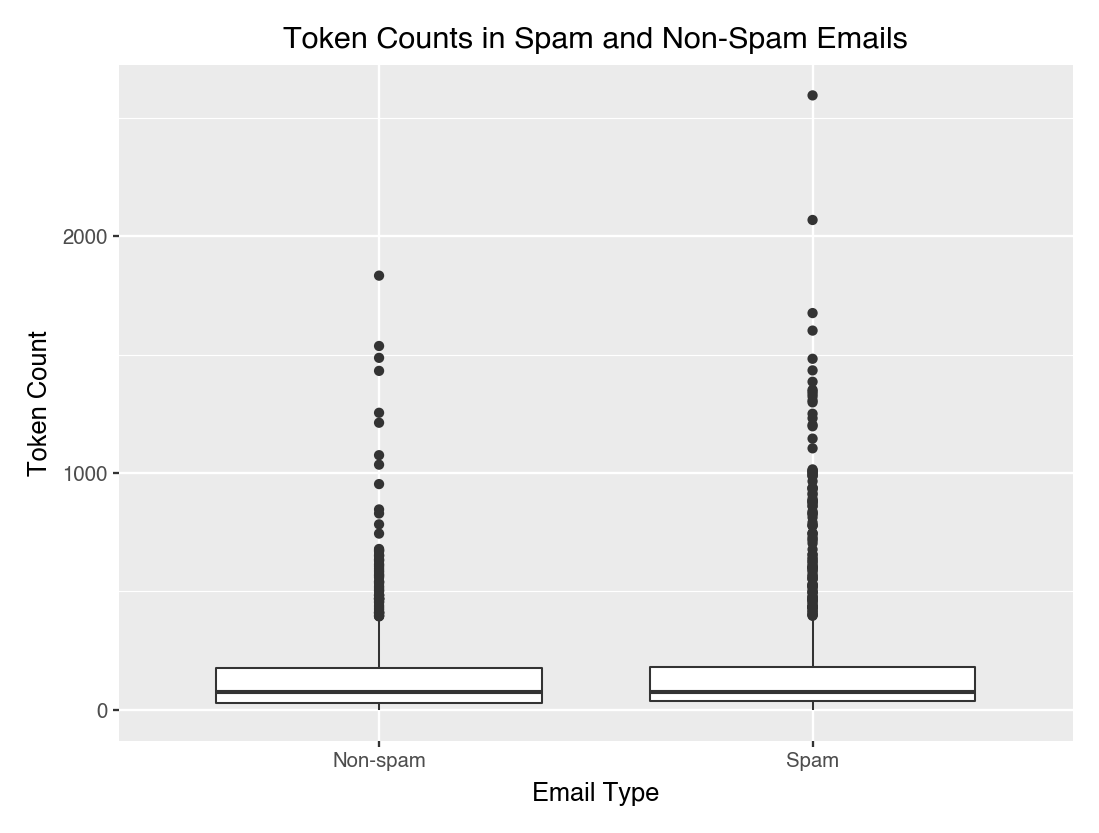

In [40]:
from plotnine import ggplot, aes, geom_boxplot, labs

known_emails["email_type"] = known_emails["spam"].map({0: "Non-spam", 1: "Spam"})
word_count_plot = ggplot(known_emails, aes(x="email_type", y="word_count")) + geom_boxplot() + labs(x="Email Type", y="Token Count", title="Token Counts in Spam and Non-Spam Emails")

word_count_plot

In [41]:
tf_means = tf.loc[known_emails.index].groupby(known_emails["email_type"]).mean()

tf_means.T

email_type,Non-spam,Spam
00,0.458291,0.342132
000,0.532663,0.166497
0000,0.000000,0.008122
000000,0.000000,0.074112
000000000002858,0.001005,0.000000
...,...,...
zyqtaqlt,0.000000,0.001015
zyyqywp,0.000000,0.001015
zzezrjok,0.000000,0.001015
zzo,0.000000,0.000000


In [42]:
top_tf_nonspam = tf_means.loc["Non-spam"].sort_values(ascending=False).head(10)

top_tf_nonspam

the      4.795980
to       3.958794
ect      3.634171
and      1.950754
hou      1.913568
for      1.875377
enron    1.609045
on       1.547739
of       1.468342
this     1.300503
Name: Non-spam, dtype: float64

In [43]:
top_tf_spam = tf_means.loc["Spam"].sort_values(ascending=False).head(10)

top_tf_spam

the     4.888325
to      3.524873
and     3.394924
of      3.084264
in      2.095431
you     1.854822
for     1.678173
this    1.559391
is      1.469036
your    1.233503
Name: Spam, dtype: float64

In [44]:
tfidf_means = tfidf.loc[known_emails.index].groupby(known_emails["email_type"]).mean()

tfidf_means.T

email_type,Non-spam,Spam
00,0.013996,0.007327
000,0.036508,0.003751
0000,0.000000,0.000258
000000,0.000000,0.000446
000000000002858,0.000229,0.000000
...,...,...
zyqtaqlt,0.000000,0.000076
zyyqywp,0.000000,0.000173
zzezrjok,0.000000,0.000058
zzo,0.000000,0.000000


In [45]:
top_tfidf_nonspam = tfidf_means.loc["Non-spam"].sort_values(ascending=False).head(10)

top_tfidf_nonspam

the      0.082967
ect      0.075379
to       0.065038
enron    0.051935
hou      0.040775
xls      0.040757
for      0.038417
000      0.036508
on       0.035399
and      0.034985
Name: Non-spam, dtype: float64

In [46]:
top_tfidf_spam = tfidf_means.loc["Spam"].sort_values(ascending=False).head(10)

top_tfidf_spam

the     0.057534
to      0.050273
and     0.049189
you     0.042117
of      0.040379
your    0.034473
in      0.029420
for     0.028624
is      0.025543
this    0.024971
Name: Spam, dtype: float64

In [47]:
comparison_words = top_tfidf_nonspam.index.union(top_tfidf_spam.index)
tfidf_comparison = tfidf_means[comparison_words].T.reset_index().rename(columns={"index": "word"})
tfidf_comparison = tfidf_comparison.melt(id_vars="word", var_name="email_type", value_name="mean_tfidf")

tfidf_comparison.head()

,word,email_type,mean_tfidf
0,000,Non-spam,0.036508
1,and,Non-spam,0.034985
2,ect,Non-spam,0.075379
3,enron,Non-spam,0.051935
4,for,Non-spam,0.038417


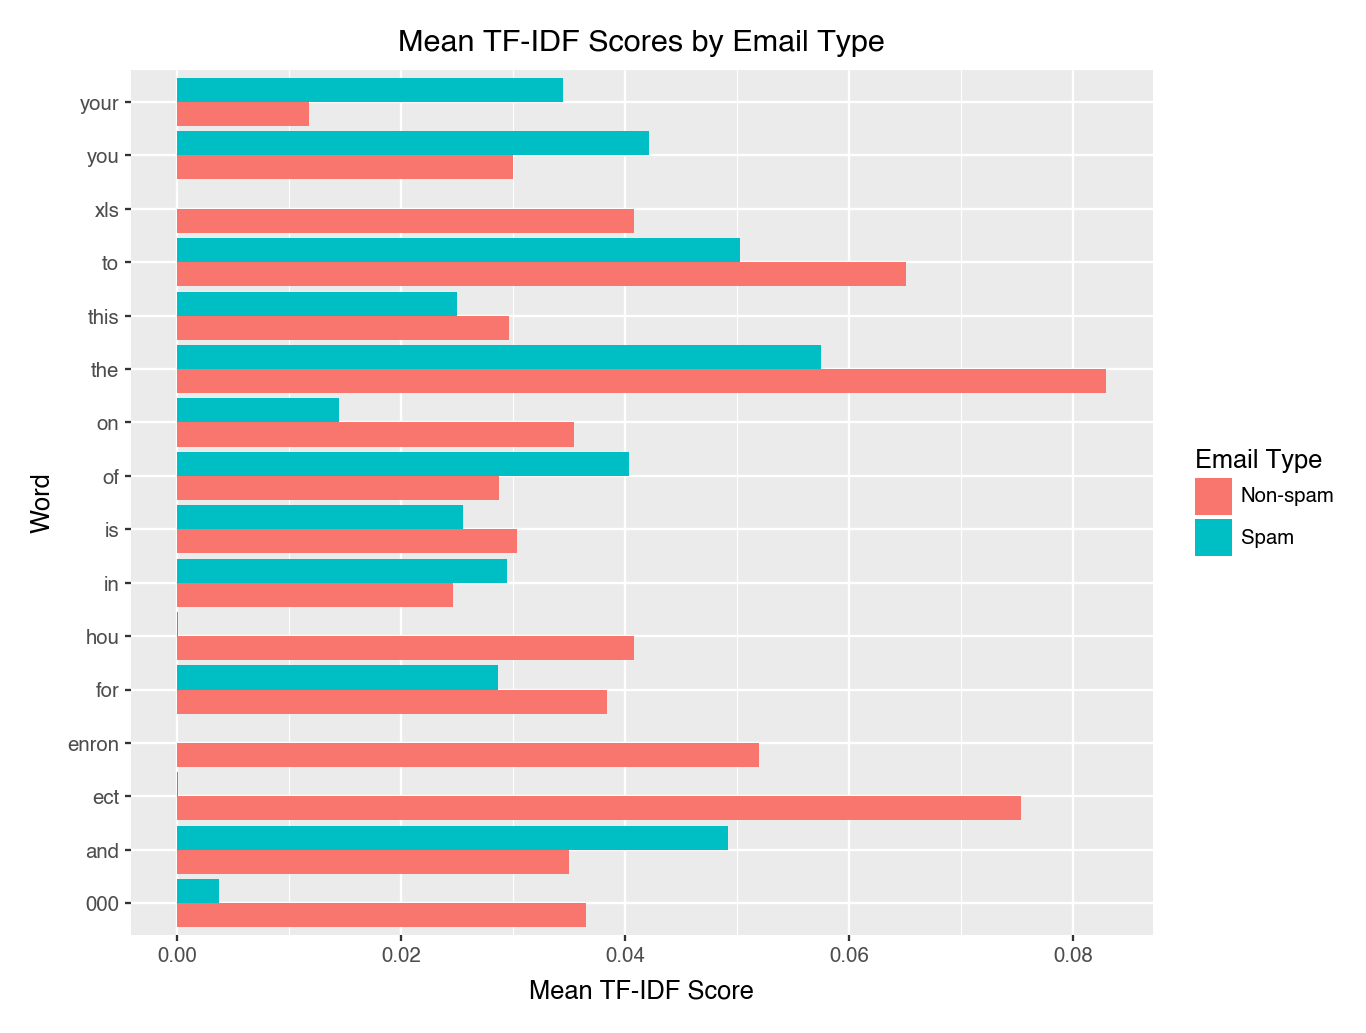

In [48]:
from plotnine import geom_col, coord_flip, theme

tfidf_plot = ggplot(tfidf_comparison, aes(x="word", y="mean_tfidf", fill="email_type")) + geom_col(position="dodge") + coord_flip() + labs(x="Word", y="Mean TF-IDF Score", fill="Email Type", title="Mean TF-IDF Scores by Email Type") + theme(figure_size=(8, 6))

tfidf_plot

Answer: Spam emails had a higher average token count of 176.19, compared with 135.33 for non-spam emails. However, both groups had a median of 74, and their boxplots looked similar in the middle. This means that longer emails are not always spam. Both groups had common words like "the" and "to" among their highest average word counts. For TF-IDF, non-spam emails included "enron" and "xls" in the top 10, while spam emails included "you" and "your". Common words still ranked highly in both groups, so these rankings alone are not enough to decide whether an email is spam.

7\. Now consider the 10 emails for which the true spam status is unknown. How might you decide if each email is spam or not? Brainstorm some ideas before proceeding. How can you use the TF and TF-IDF matrices for emails with known spam status?

Answer: First, I would compare each unknown email with the emails whose spam status is known. Second, I would use their TF or TF-IDF values to calculate cosine distances. A smaller distance means the emails are more similar in their word use. Third, I would look at the spam labels of the closest emails. If most of them are spam, I would guess that the unknown email is also spam. Otherwise, I would guess non-spam. I would compare the guesses from TF and TF-IDF to see whether they agree. These would still be guesses because similar word use does not always mean the emails belong to the same group.

8\. Consider just one email with unknown spam status, with `loc` 1980. Compute the cosine distance between the TF representation of this email and the TF representation of each of the emails with known spam status.

In [49]:
from sklearn.metrics.pairwise import cosine_distances

tf_distances = pd.Series(cosine_distances(tf.loc[[1980]], tf.loc[known_emails.index])[0], index=known_emails.index, name="cosine_distance")

tf_distances.head()

0    0.736928
1    0.542990
2    0.775802
3    0.653954
4    0.519088
Name: cosine_distance, dtype: float64

9\. Sort the results of the previous part to examine the emails with known spam status that are most similar to the unknown email. If you had to determine if the unknown email was spam or not, which would you pick and why?

In [50]:
nearest_tf = tf_distances.sort_values().head(5)
nearest_tf_results = known_emails.loc[nearest_tf.index, ["spam"]].copy()
nearest_tf_results["cosine_distance"] = nearest_tf

nearest_tf_results

,spam,cosine_distance
1889,1.0,0.393060
1032,1.0,0.398488
1376,1.0,0.408606
714,0.0,0.414644
1110,1.0,0.415807


Answer: I think that email 1980 is spam. Four of its five closest emails are spam, and the closest email which is 1889, is also spam with a cosine distance of about 0.393. This suggests that its word use is more similar to spam emails. However, one of the five closest emails is non-spam, so this is a guess rather than a certain answer.

10\. Repeat the two previous parts using TF-IDF instead of TF. Do the results change?

In [51]:
tfidf_distances = pd.Series(cosine_distances(tfidf.loc[[1980]], tfidf.loc[known_emails.index])[0], index=known_emails.index, name="cosine_distance")
nearest_tfidf = tfidf_distances.sort_values().head(5)
nearest_tfidf_results = known_emails.loc[nearest_tfidf.index, ["spam"]].copy()
nearest_tfidf_results["cosine_distance"] = nearest_tfidf

nearest_tfidf_results

,spam,cosine_distance
1032,1.0,0.755245
1977,1.0,0.780917
48,0.0,0.787975
1689,1.0,0.790205
1796,1.0,0.795094


Answer: The closest emails and their distances changed when I used TF-IDF instead of TF. With TF, the closest email was 1889 with a distance of about 0.393. With TF-IDF, the closest email was 1032 with a distance of about 0.755. However, four of the five closest emails were spam in both cases, so I still think that email 1980 is spam. The two methods gave the same guess, but this does not guarantee that it is correct.

11\. Now proceed in a similar manner to "guess" the spam status of each of the unknown emails.

In [52]:
unknown_emails = emails.loc[emails["spam"].isna()].copy()

unknown_emails[["subject", "spam"]]

,subject,spam
1980,let ' s talk about your home loan .,NaN
1981,intraday eastrans nomination change for 9 / 6 ...,NaN
1982,"frontrea plant , gas",NaN
1983,re : meter 5892,NaN
1984,eastrans nomination change effective 8 / 3 / 00,NaN
1985,customer reciept # 4359 bn winkle,NaN
1986,internet pharmacy - smart prices,NaN
1987,victory at last,NaN
1988,free pay per view,NaN
1989,87 % off for all new software . darned canniba...,NaN


In [53]:
unknown_tf_distances = pd.DataFrame(cosine_distances(tf.loc[unknown_emails.index], tf.loc[known_emails.index]), index=unknown_emails.index, columns=known_emails.index)

unknown_tf_distances.shape

(10, 1980)

In [54]:
nearest_tf_indices = unknown_tf_distances.apply(lambda row: row.sort_values().head(5).index.tolist(), axis=1)

nearest_tf_indices

1980     [1889, 1032, 1376, 714, 1110]
1981          [937, 564, 836, 428, 17]
1982       [718, 744, 1666, 1725, 374]
1983         [849, 270, 775, 185, 208]
1984         [380, 749, 767, 146, 214]
1985      [1028, 667, 846, 1372, 1958]
1986    [1141, 1225, 1395, 1428, 1172]
1987    [1262, 1362, 1155, 1372, 1958]
1988    [1933, 1416, 1514, 1026, 1121]
1989       [381, 245, 1779, 1504, 634]
dtype: object

In [55]:
tf_spam_votes = nearest_tf_indices.apply(lambda indices: known_emails.loc[indices, "spam"].sum()).astype(int)

tf_spam_votes

1980    4
1981    0
1982    2
1983    0
1984    0
1985    3
1986    5
1987    5
1988    5
1989    2
dtype: int64

In [56]:
tf_predictions = (tf_spam_votes >= 3).astype(int)

tf_predictions

1980    1
1981    0
1982    0
1983    0
1984    0
1985    1
1986    1
1987    1
1988    1
1989    0
dtype: int64

In [57]:
unknown_tfidf_distances = pd.DataFrame(cosine_distances(tfidf.loc[unknown_emails.index], tfidf.loc[known_emails.index]), index=unknown_emails.index, columns=known_emails.index)

unknown_tfidf_distances.shape

(10, 1980)

In [58]:
nearest_tfidf_indices = unknown_tfidf_distances.apply(lambda row: row.sort_values().head(5).index.tolist(), axis=1)

nearest_tfidf_indices

1980      [1032, 1977, 48, 1689, 1796]
1981          [836, 428, 17, 564, 767]
1982        [718, 1666, 751, 354, 744]
1983          [579, 270, 849, 25, 979]
1984         [380, 749, 146, 214, 767]
1985     [1028, 1633, 1412, 1893, 667]
1986    [1141, 1932, 1346, 1225, 1894]
1987    [1976, 1262, 1626, 1155, 1032]
1988    [1121, 1933, 1026, 1735, 1500]
1989       [245, 381, 961, 1413, 1779]
dtype: object

In [59]:
tfidf_spam_votes = nearest_tfidf_indices.apply(lambda indices: known_emails.loc[indices, "spam"].sum()).astype(int)

tfidf_spam_votes

1980    4
1981    0
1982    1
1983    0
1984    0
1985    4
1986    5
1987    5
1988    5
1989    2
dtype: int64

In [60]:
tfidf_predictions = (tfidf_spam_votes >= 3).astype(int)

tfidf_predictions

1980    1
1981    0
1982    0
1983    0
1984    0
1985    1
1986    1
1987    1
1988    1
1989    0
dtype: int64

In [61]:
prediction_comparison = pd.DataFrame({"TF spam votes": tf_spam_votes, "TF prediction": tf_predictions, "TF-IDF spam votes": tfidf_spam_votes, "TF-IDF prediction": tfidf_predictions})
prediction_comparison["Agree"] = prediction_comparison["TF prediction"] == prediction_comparison["TF-IDF prediction"]

prediction_comparison

,TF spam votes,TF prediction,TF-IDF spam votes,TF-IDF prediction,Agree
1980,4,1,4,1,True
1981,0,0,0,0,True
1982,2,0,1,0,True
1983,0,0,0,0,True
1984,0,0,0,0,True
1985,3,1,4,1,True
1986,5,1,5,1,True
1987,5,1,5,1,True
1988,5,1,5,1,True
1989,2,0,2,0,True


Answer: For this question, I used the five closest known emails to guess the spam status of each unknown email. If at least three were spam, I guessed spam. TF and TF-IDF gave the same predictions for all 10 emails. Both methods predicted that emails 1980, 1985, 1986, 1987, and 1988 were spam, while emails 1981, 1982, 1983, 1984, and 1989 were non-spam. Some vote counts changed, but the final predictions stayed the same. Since the true labels are unknown, agreement between the two methods does not mean the predictions must be correct.